<a href="https://colab.research.google.com/github/fynoeb/2311537001-fayiamatullahazhara-semester2/blob/master/TextMiningK1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ------------------------------------------------------------------------------
# BAGIAN 0: INSTALASI DAN IMPORT LIBRARY
# ------------------------------------------------------------------------------
print("Menginstal library yang dibutuhkan...")
!pip install spacy pandas matplotlib seaborn --quiet
!python -m spacy download xx_ent_wiki_sm --quiet

import spacy
from spacy.lang.id import Indonesian
from spacy.pipeline import EntityRuler
from spacy.tokens import DocBin
from spacy.scorer import Scorer
from spacy.training import Example
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings

# Mengabaikan warning yang tidak relevan dari spaCy
warnings.filterwarnings("ignore", message=r"\[W007\]", category=UserWarning)
warnings.filterwarnings("ignore", message=r"\[W033\]", category=UserWarning)

print("\nLibrary berhasil di-load.")

Menginstal library yang dibutuhkan...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 49.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('xx_ent_wiki_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.

Library berhasil di-load.


BAGIAN 1: PENGUMPULAN DAN PERSIAPAN DATA (TAHAP 1)

In [ ]:
try:
    # Membaca file CSV dengan pemisah semikolon (;)
    df = pd.read_csv('/content/merged_news_data.csv', sep=';')

    # Mengganti nama kolom untuk kemudahan
    df.columns = ['link', 'title', 'tags', 'content']

    # Membersihkan data dari baris yang mungkin kosong
    df = df.dropna(subset=['content'])

    # Menghapus duplikat berdasarkan konten
    df = df.drop_duplicates(subset=['content'])

    # Implementasi Tahap 1.b: Preprocessing sederhana
    # (Menghapus 'nan' dan teks 'Sumber:...' di akhir artikel)
    def clean_text(text):
        text = str(text)
        # Menghapus 'nan' yang sering muncul
        text = text.replace(' nan', ' ').strip()
        # Menghapus 'Disadur dari...' atau 'Sumber:...'
        text = re.sub(r"(Disadur dari|Sumber:).*", "", text, flags=re.IGNORECASE)
        # Menghapus spasi berlebih
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    df['content_cleaned'] = df['content'].apply(clean_text)

    print(f"Berhasil memuat {len(df)} artikel berita olahraga.")
    print("Contoh data (5 baris pertama):")
    print(df[['title', 'content_cleaned']].head())

except FileNotFoundError:
    print("\n[ERROR] File 'merged_news_data.csv' tidak ditemukan.")
    print("Pastikan Anda sudah meng-upload file tersebut ke Google Colab.")

except Exception as e:
    print(f"\n[ERROR] Terjadi kesalahan saat memuat data: {e}")

Berhasil memuat 50 artikel berita olahraga.
Contoh data (5 baris pertama):
                                               title  \
0  3 Catatan Menarik dari Kekalahan 0-4 Timnas In...   
1  3 Target Besar Pelatih Baru Timnas Indonesia: ...   
2  5 Pemain Kunci Timnas Indonesia U-17 di Piala ...   
3  Apresiasi Performa Timnas Indonesia U-17 Meski...   
4  Bukan Cuma Rumor? Timur Kapadze: Saya Sedang B...   

                                     content_cleaned  
0  Bola.net - Timnas Indonesia U-17 harus mengaku...  
1  Bola.net - Calon pelatih baru Timnas Indonesia...  
2  Bola.net - Piala Dunia U-17 telah melahirkan b...  
3  Bola.net - Timnas Indonesia U-17 memang kalah ...  
4  Bola.net - Timur Kapadze memberi sinyal kuat b...  


BAGIAN 2: IMPLEMENTASI MODEL NER (TAHAP 2)

In [ ]:
# Fokus NER Kelompok 1: PERSON, ORGANIZATION, EVENT, LOCATION

# 2.a. Memuat model Deep Learning (xx_ent_wiki_sm)
# Model ini sudah bisa mendeteksi PER (Person), ORG (Organization), dan LOC (Location)
print("Memuat model spaCy multilingual (xx_ent_wiki_sm)...")
nlp = spacy.load('xx_ent_wiki_sm')

# 2.b. Pendekatan Rule-Based (EntityRuler) untuk 'EVENT'
# Kita mendefinisikan event penting secara manual berdasarkan data
# Ini untuk menangani entitas 'EVENT' yang tidak dikenal model pre-trained.
print("Menambahkan aturan (rules) kustom untuk entitas 'EVENT'...")
event_patterns = [
    {"label": "EVENT", "pattern": "Piala Dunia U-17 2025"},
    {"label": "EVENT", "pattern": "Piala Dunia U-17 2023"},
    {"label": "EVENT", "pattern": "Piala Dunia U-17"},
    {"label": "EVENT", "pattern": "Piala Dunia 2026"},
    {"label": "EVENT", "pattern": "Piala Dunia 2030"},
    {"label": "EVENT", "pattern": "Piala Asia 2027"},
    {"label": "EVENT", "pattern": "Piala Asia 2023"},
    {"label": "EVENT", "pattern": "Piala Asia"},
    {"label": "EVENT", "pattern": "FIFA ASEAN Cup"},
    {"label": "EVENT", "pattern": "Piala AFF"},
    {"label": "EVENT", "pattern": "SEA Games 2025"},
    {"label": "EVENT", "pattern": "Kualifikasi Piala Dunia 2026"},
    {"label": "EVENT", "pattern": "BRI Super League"},
    {"label": "EVENT", "pattern": "AFC Champions League Two"},
    {"label": "EVENT", "pattern": "ACL 2"},
    {"label": "EVENT", "pattern": "Euro 2016"}
]

# Membuat EntityRuler dan menambahkannya ke pipeline nlp
ruler = nlp.add_pipe("entity_ruler", before="ner")
ruler.add_patterns(event_patterns)

# Fungsi untuk memproses teks dan mengekstrak entitas sesuai target
def extract_entities(text):
    doc = nlp(text)
    entities = []
    # Label yang dikenali model 'xx': PER, ORG, LOC
    # Label dari 'ruler': EVENT
    target_labels = {"PER": "PERSON", "ORG": "ORGANIZATION", "LOC": "LOCATION", "EVENT": "EVENT"}

    for ent in doc.ents:
        if ent.label_ in target_labels:
            entities.append({
                "text": ent.text,
                "label": target_labels[ent.label_]
            })
    return entities

# Mari kita uji pada satu artikel
print("\nContoh hasil NER pada 1 artikel:")
sample_text = df['content_cleaned'].iloc[0] #
sample_entities = extract_entities(sample_text)
print(f"Teks: {sample_text[:150]}...")
print(f"Entitas: {sample_entities[:5]}...")

Memuat model spaCy multilingual (xx_ent_wiki_sm)...
Menambahkan aturan (rules) kustom untuk entitas 'EVENT'...

Contoh hasil NER pada 1 artikel:
Teks: Bola.net - Timnas Indonesia U-17 harus mengakui keunggulan Brasil U-17 setelah menelan kekalahan 0-4 pada laga Grup H Piala Dunia U-17 2025. Pertandin...
Entitas: [{'text': 'Brasil', 'label': 'LOCATION'}, {'text': 'Grup H', 'label': 'LOCATION'}, {'text': 'Piala Dunia U-17 2025', 'label': 'EVENT'}, {'text': 'Pertandingan', 'label': 'PERSON'}, {'text': 'Lapangan', 'label': 'PERSON'}]...


BAGIAN 3: ANALISIS DAN VISUALISASI (TAHAP 4)

Mengekstrak entitas dari seluruh artikel...


/tmp/ipython-input-681053971.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_entities['label'], order=df_entities['label'].value_counts().index, palette="viridis")


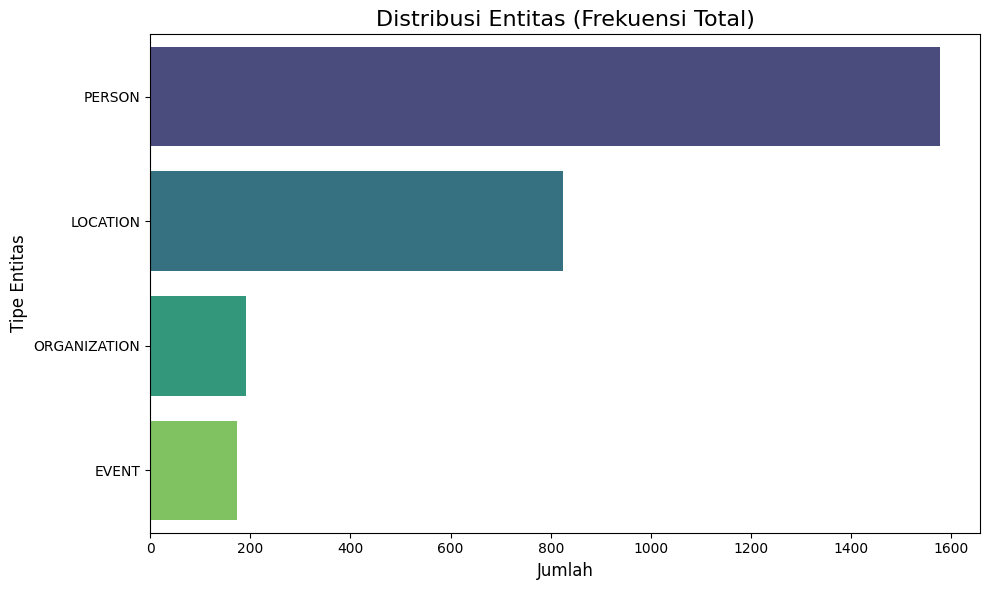


Data Frekuensi Entitas:
label
PERSON          1578
LOCATION         825
ORGANIZATION     191
EVENT            174
Name: count, dtype: int64


/tmp/ipython-input-681053971.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_entities.index, x=top_entities.values, palette="rocket")


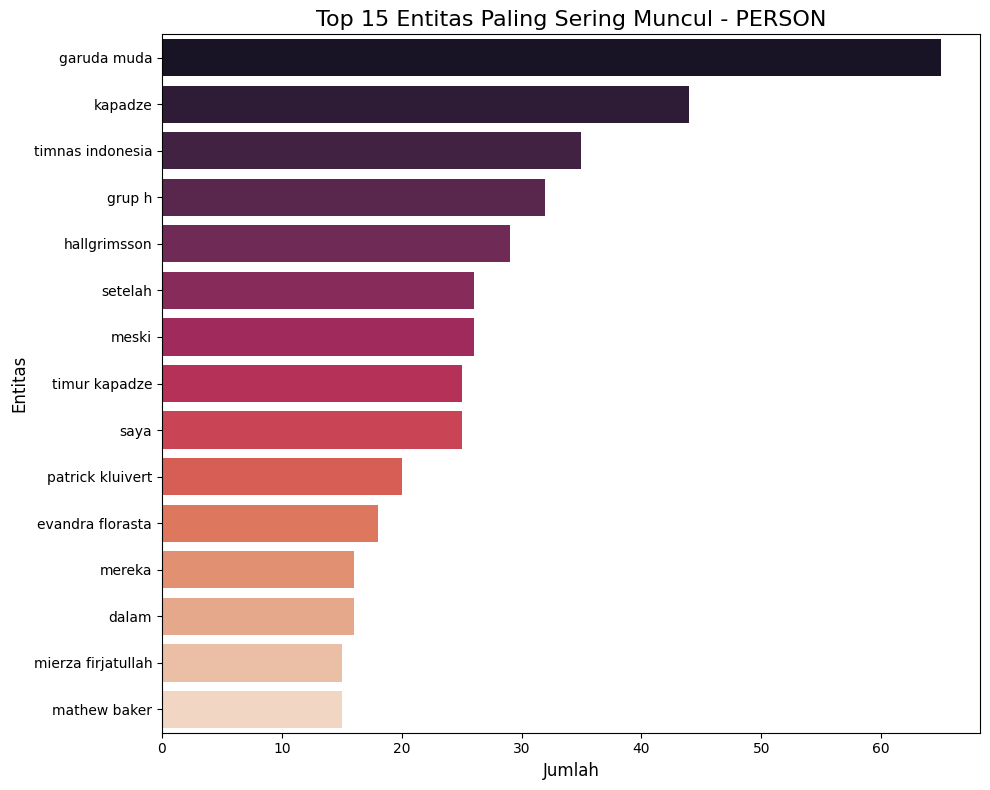

/tmp/ipython-input-681053971.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_entities.index, x=top_entities.values, palette="rocket")


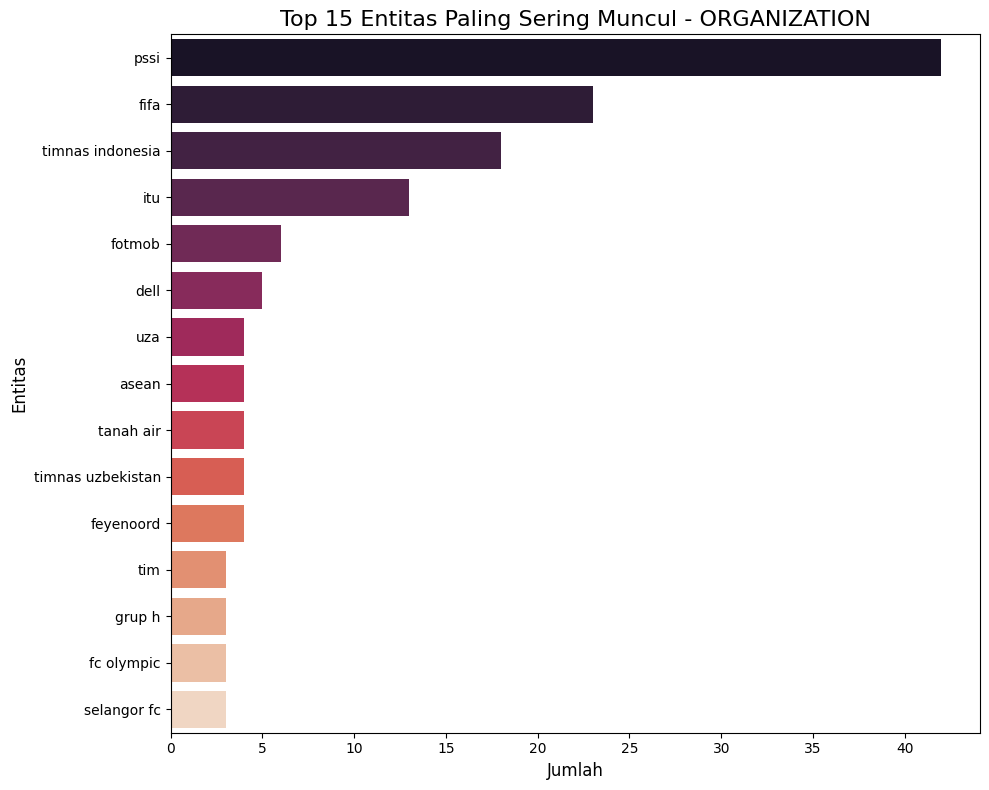

/tmp/ipython-input-681053971.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_entities.index, x=top_entities.values, palette="rocket")


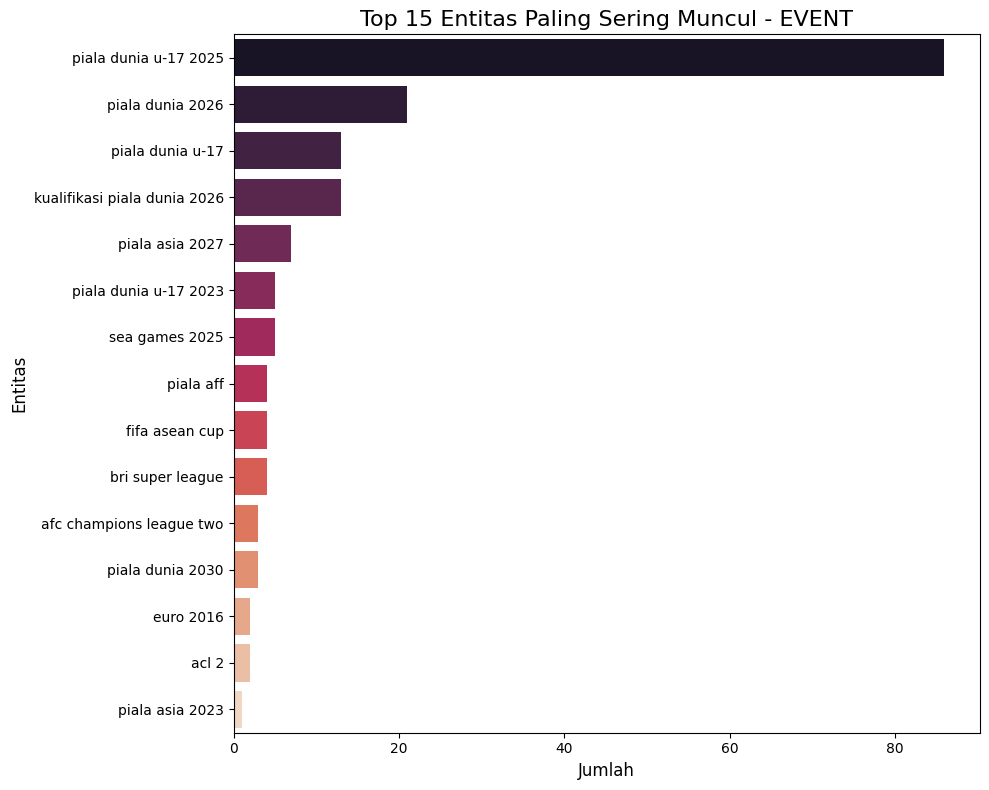

/tmp/ipython-input-681053971.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_entities.index, x=top_entities.values, palette="rocket")


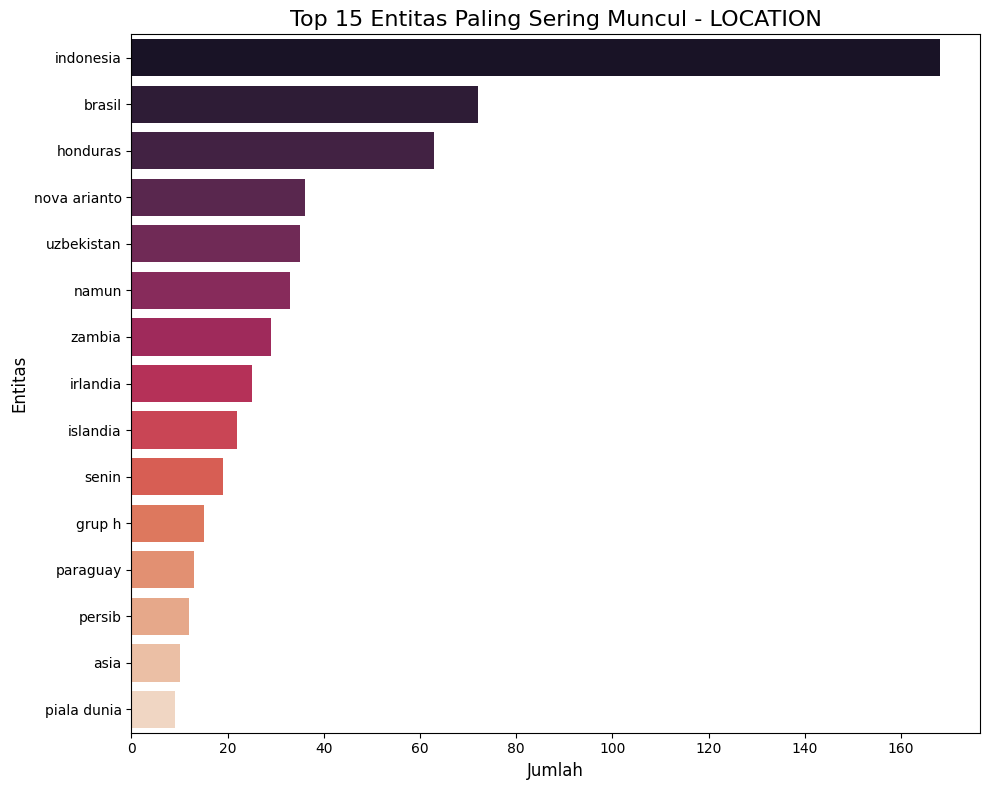

In [ ]:
# 3.a. Ekstraksi entitas dari seluruh dataset
print("Mengekstrak entitas dari seluruh artikel...")
all_entities = []
for content in df['content_cleaned']:
    all_entities.extend(extract_entities(content))

# Konversi ke DataFrame untuk analisis
df_entities = pd.DataFrame(all_entities)

if df_entities.empty:
    print("[WARNING] Tidak ada entitas yang terdeteksi. Melompati visualisasi.")
else:
    # 3.b. Menganalisis distribusi dan frekuensi entitas
    plt.figure(figsize=(10, 6))
    sns.countplot(y=df_entities['label'], order=df_entities['label'].value_counts().index, palette="viridis")
    plt.title('Distribusi Entitas (Frekuensi Total)', fontsize=16)
    plt.xlabel('Jumlah', fontsize=12)
    plt.ylabel('Tipe Entitas', fontsize=12)
    plt.tight_layout()
    plt.show() #

    print("\nData Frekuensi Entitas:")
    print(df_entities['label'].value_counts())

    # 3.c. Memvisualisasikan entitas paling umum per kategori
    #
    def plot_top_entities(label, n=15):
        plt.figure(figsize=(10, 8))
        # Filter entitas berdasarkan label
        data = df_entities[df_entities['label'] == label]

        if data.empty:
            print(f"Tidak ditemukan entitas untuk label: {label}")
            return

        # Normalisasi teks (contoh: "Nova Arianto" dan "Nova arianto" dihitung sama)
        top_entities = data['text'].str.lower().value_counts().head(n)

        sns.barplot(y=top_entities.index, x=top_entities.values, palette="rocket")
        plt.title(f'Top {n} Entitas Paling Sering Muncul - {label}', fontsize=16)
        plt.xlabel('Jumlah', fontsize=12)
        plt.ylabel('Entitas', fontsize=12)
        plt.tight_layout()
        plt.show()

    # Visualisasi untuk setiap fokus NER Kelompok 1
    plot_top_entities('PERSON')
    plot_top_entities('ORGANIZATION')
    plot_top_entities('EVENT')
    plot_top_entities('LOCATION')

BAGIAN 4: OUTPUT TAMBAHAN KELOMPOK 1 (TAHAP 5)

In [ ]:
if df_entities.empty:
    print("[WARNING] Tidak ada entitas, analisis tambahan tidak dapat dilakukan.")
else:
    # 4.a. Menemukan event, person, dan organization yang paling sering dibahas
    top_events = df_entities[df_entities['label'] == 'EVENT']['text'].str.lower().value_counts().head(3).index
    top_orgs = df_entities[df_entities['label'] == 'ORGANIZATION']['text'].str.lower().value_counts().head(10).index
    top_persons = df_entities[df_entities['label'] == 'PERSON']['text'].str.lower().value_counts().head(10).index

    print(f"Top 3 Event yang dianalisis: {list(top_events)}")
    print(f"Top 10 Tim/Organisasi: {list(top_orgs)}")
    print(f"Top 10 Atlet/Pelatih: {list(top_persons)}")

    # 4.b. Membuat fungsi untuk mencari co-occurrence (kemunculan bersama)
    def analyze_cooccurrence(event_name):
        person_counter = Counter()
        org_counter = Counter()

        # Iterasi setiap artikel
        for text in df['content_cleaned']:
            text_lower = text.lower()
            # Cek jika event dibahas di artikel ini
            if event_name in text_lower:
                # Jika ya, cari semua PERSON dan ORG di artikel yang sama
                doc_entities = extract_entities(text)
                for ent in doc_entities:
                    ent_text_lower = ent['text'].lower()
                    if ent['label'] == 'PERSON' and ent_text_lower in top_persons:
                        person_counter[ent['text']] += 1
                    elif ent['label'] == 'ORGANIZATION' and ent_text_lower in top_orgs:
                        org_counter[ent['text']] += 1
        return person_counter, org_counter

    # 4.c. Menampilkan hasil analisis
    print("\nAnalisis Hubungan Atlet/Tim dengan Event Tertentu:")

    for event in top_events:
        print(f"\n--- Event: '{event.title()}' ---")
        persons, orgs = analyze_cooccurrence(event)

        if not persons and not orgs:
            print("Tidak ditemukan keterkaitan menonjol di data.")
            continue

        print("-> Top 5 Tim/Organisasi Terkait:")
        if orgs:
            for org, count in orgs.most_common(5):
                print(f"   - {org} (disebut {count} kali bersama event)")
        else:
            print("   - (Tidak ada)")

        print("-> Top 5 Atlet/Pelatih Terkait:")
        if persons:
            for person, count in persons.most_common(5):
                print(f"   - {person} (disebut {count} kali bersama event)")
        else:
            print("   - (Tidak ada)")

Top 3 Event yang dianalisis: ['piala dunia u-17 2025', 'piala dunia 2026', 'piala dunia u-17']
Top 10 Tim/Organisasi: ['pssi', 'fifa', 'timnas indonesia', 'itu', 'fotmob', 'dell', 'uza', 'asean', 'tanah air', 'timnas uzbekistan']
Top 10 Atlet/Pelatih: ['garuda muda', 'kapadze', 'timnas indonesia', 'grup h', 'hallgrimsson', 'setelah', 'meski', 'timur kapadze', 'saya', 'patrick kluivert']

Analisis Hubungan Atlet/Tim dengan Event Tertentu:

--- Event: 'Piala Dunia U-17 2025' ---
-> Top 5 Tim/Organisasi Terkait:
   - FIFA (disebut 15 kali bersama event)
   - FotMob (disebut 6 kali bersama event)
   - Dell (disebut 5 kali bersama event)
   - itu (disebut 4 kali bersama event)
   - Tanah Air (disebut 1 kali bersama event)
-> Top 5 Atlet/Pelatih Terkait:
   - Garuda Muda (disebut 63 kali bersama event)
   - Grup H (disebut 32 kali bersama event)
   - Meski (disebut 16 kali bersama event)
   - Setelah (disebut 10 kali bersama event)
   - Saya (disebut 1 kali bersama event)

--- Event: 'Piala 